<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 1. Импорт библиотек + вводная обработка </span>
<a id = "Undertanding the data" ></a>

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv


In [3]:
df = pd.read_csv("/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv")
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 2. Описание данных </span>
<a id = "Undertanding the data" ></a>

| Column | Description |
|------|-------------|
| age | Возраст человека (в годах). Числовой признак, отражает возраст респондента. |
| workclass | Тип занятости или сектор работы (например: Private, Self-employed, Government). Показывает, в каком типе организации работает человек. |
| fnlwgt | Final weight — статистический вес записи в выборке переписи. Используется Census Bureau для корректного представления населения (одна запись может представлять несколько людей в популяции). |
| education | Уровень образования человека (например: Bachelors, HS-grad, Masters). Категориальный признак. |
| educational-num | Числовое представление уровня образования. Чем выше число, тем выше уровень образования. Например, Bachelors ≈ 13. |
| marital-status | Семейное положение (Married, Never-married, Divorced и т.д.). |
| occupation | Профессия или тип выполняемой работы (например: Tech-support, Sales, Exec-managerial). |
| relationship | Отношение человека к главе домохозяйства (например: Husband, Wife, Not-in-family, Own-child). |
| race | Расовая принадлежность (например: White, Black, Asian-Pac-Islander). |
| gender | Пол человека (Male или Female). |
| capital-gain | Доход от инвестиций или продажи активов (например акции, недвижимость), если прибыль была получена. |
| capital-loss | Убытки от инвестиций или продажи активов. |
| hours-per-week | Среднее количество рабочих часов в неделю. |
| native-country | Страна происхождения человека. |
| income | Целевая переменная (target): годовой доход человека. Обычно две категории: `<=50K` или `>50K`. |

| Category | Meaning |
|--------|--------|
| Private | Работа в частной компании |
| Self-emp-not-inc | Самозанятый (без зарегистрированного бизнеса) |
| Self-emp-inc | Самозанятый (с зарегистрированным бизнесом) |
| Federal-gov | Работа в федеральном правительстве США |
| Local-gov | Работа в местных органах власти |
| State-gov | Работа в органах власти штата |
| Without-pay | Работает без оплаты (например, волонтёр или семейный бизнес) |
| Never-worked | Никогда не работал |
| is_unemployed | Не имеет текущей работы (добавленная тобой категория) |

In [5]:
from sklearn.model_selection import train_test_split

x = df.drop(columns = "income")
y = df["income"]

x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
x_train_original = x_train.copy()
x_train_original.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,71,Private,77253,HS-grad,9,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,17,United-States
18559,17,Private,329783,10th,6,Never-married,Sales,Other-relative,White,Female,0,0,10,United-States
12477,27,Private,91257,HS-grad,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,El-Salvador
560,43,Private,125577,HS-grad,9,Separated,Adm-clerical,Unmarried,Black,Female,0,0,40,United-States
3427,31,Private,137978,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States


In [7]:
x_test_original = x_test.copy()
x_test_original.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
40342,54,Private,115602,HS-grad,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,40,United-States
47680,28,Local-gov,401886,HS-grad,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States
524,53,Local-gov,139671,Some-college,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States
8508,58,Private,177368,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,3137,0,16,United-States
31692,47,Local-gov,352614,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States


In [8]:
len(x_train_original.columns)

14

In [9]:
x_train = x_train.drop("fnlwgt", axis = 1)



In [10]:
x_train = x_train.drop("education", axis = 1)
x_train.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,71,Private,9,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,17,United-States
18559,17,Private,6,Never-married,Sales,Other-relative,White,Female,0,0,10,United-States
12477,27,Private,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,El-Salvador
560,43,Private,9,Separated,Adm-clerical,Unmarried,Black,Female,0,0,40,United-States
3427,31,Private,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States


In [11]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 39073 entries, 34342 to 42656
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              39073 non-null  int64 
 1   workclass        39073 non-null  object
 2   educational-num  39073 non-null  int64 
 3   marital-status   39073 non-null  object
 4   occupation       39073 non-null  object
 5   relationship     39073 non-null  object
 6   race             39073 non-null  object
 7   gender           39073 non-null  object
 8   capital-gain     39073 non-null  int64 
 9   capital-loss     39073 non-null  int64 
 10  hours-per-week   39073 non-null  int64 
 11  native-country   39073 non-null  object
dtypes: int64(5), object(7)
memory usage: 3.9+ MB


In [12]:
columns = x_train.columns

## Типы данных

In [13]:
binary_cols = [col for col in x_train.columns if x_train[col].nunique()==2]
x_train[binary_cols] # 1 признак

,gender
34342,Male
18559,Female
12477,Male
560,Female
3427,Male
...,...
38073,Male
16306,Male
26860,Male
20602,Male


In [14]:
numeric_cols = [col for col in x_train.columns if x_train[col].dtype in ["int64", "float64"]]
numeric_cols.remove("educational-num")
x_train[numeric_cols] #4 штуки
#можем заметить, что capital-gain, capital-loss - имеет много нулевых значений


,age,capital-gain,capital-loss,hours-per-week
34342,71,0,0,17
18559,17,0,0,10
12477,27,0,0,40
560,43,0,0,40
3427,31,0,0,40
...,...,...,...,...
38073,33,0,0,60
16306,56,0,0,40
26860,36,0,0,40
20602,32,0,0,40


In [15]:
categorical_cols = [
    col for col in x_train.columns 
    if x_train[col].dtype == "object" and x_train[col].nunique() > 2]
x_train[categorical_cols] #7 категориальных признаков


,workclass,marital-status,occupation,relationship,race,native-country
34342,Private,Never-married,Handlers-cleaners,Not-in-family,White,United-States
18559,Private,Never-married,Sales,Other-relative,White,United-States
12477,Private,Married-civ-spouse,Other-service,Husband,White,El-Salvador
560,Private,Separated,Adm-clerical,Unmarried,Black,United-States
3427,Private,Married-civ-spouse,Exec-managerial,Husband,White,United-States
...,...,...,...,...,...,...
38073,Private,Married-civ-spouse,Sales,Husband,White,United-States
16306,Local-gov,Married-civ-spouse,Tech-support,Husband,White,United-States
26860,Private,Married-civ-spouse,Machine-op-inspct,Husband,White,United-States
20602,Private,Married-civ-spouse,Adm-clerical,Husband,White,United-States


<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 3. Обработка данных  (baseline)</span>
<a id = "Undertanding the data" ></a>

## Бинарные признаки

In [16]:
x_train[binary_cols].value_counts()

gender
Male      26140
Female    12933
Name: count, dtype: int64

In [17]:
x_train[binary_cols].isnull().sum()

gender    0
dtype: int64

<Axes: xlabel='gender', ylabel='count'>

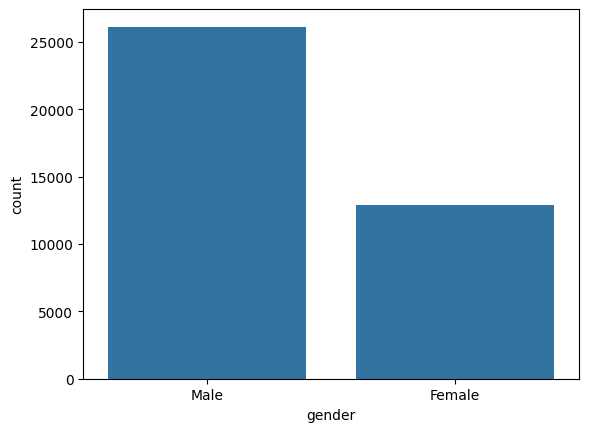

In [18]:
sns.countplot(data=x_train, x='gender')


## Числовые признаки

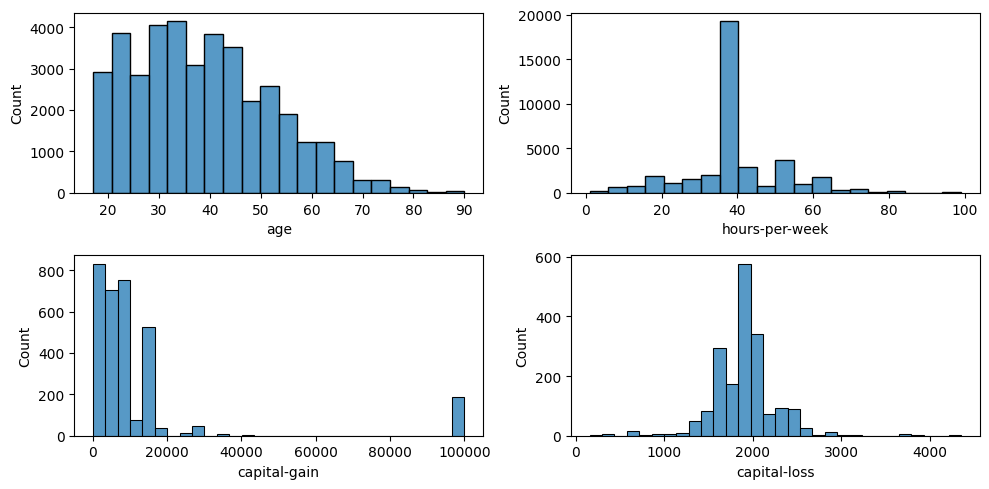

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(10,5))
axes = axes.flatten()

sns.histplot(data = x_train, x='age', bins=20, ax=axes[0])
sns.histplot(data = x_train, x='hours-per-week', bins=20, ax=axes[1])
sns.histplot(
    x_train[x_train["capital-gain"] > 0]["capital-gain"],
    bins=30, ax=axes[2]
)
sns.histplot(
    x_train[x_train["capital-loss"] > 0]["capital-loss"],
    bins=30, ax=axes[3]
)

plt.tight_layout()
plt.show()

In [20]:
x_train["has_capital_gain"] = (x_train["capital-gain"] > 0).astype(int)
x_train["has_capital_loss"] = (x_train["capital-loss"] > 0).astype(int)
x_train

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,has_capital_gain,has_capital_loss
34342,71,Private,9,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,17,United-States,0,0
18559,17,Private,6,Never-married,Sales,Other-relative,White,Female,0,0,10,United-States,0,0
12477,27,Private,9,Married-civ-spouse,Other-service,Husband,White,Male,0,0,40,El-Salvador,0,0
560,43,Private,9,Separated,Adm-clerical,Unmarried,Black,Female,0,0,40,United-States,0,0
3427,31,Private,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38073,33,Private,9,Married-civ-spouse,Sales,Husband,White,Male,0,0,60,United-States,0,0
16306,56,Local-gov,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,0,0
26860,36,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,0,0
20602,32,Private,9,Married-civ-spouse,Adm-clerical,Husband,White,Male,0,0,40,United-States,0,0


In [21]:
my_features = ["has_capital_gain", "has_capital_loss"]

In [22]:
#я предполага, что будет пересечение, мол если ты уже играешь на бирже, то будут и потери и убытки
#но кажется здесь большая часть данных про продажу активов))
pd.crosstab(
    x_train["has_capital_gain"],
    x_train["has_capital_loss"]
)

has_capital_loss,0,1
has_capital_gain,,
0,34007,1872
1,3194,0


Так, предполагаю что можно создать фичу - наличие дохода от инвестиций. Думаю среди таких людей, будет сильно больше богатых.

+ можно будет сделать log трансформацию


Большинство людей в трудоспособном возрасте. Распределение похоже на нормальное, но со сдвигом в право

Здесь такие признаки, будто все могут влиять на доход
гипотезы: 
1) чем старше, тем богаче (мол больше опыта)
2) будто все кто не работают 40 часов, могут оказаться богаче
3) наличие дохода от инвестиций должно приводить к деньгам

п.с. мне показалось что здесь нет реальных выбросов (т.е. все выбросы, это полезные значения, так что в итоге я ничего не удаляла)

## Категориальные признаки

In [23]:
for col in categorical_cols:
    print(x_train[col].value_counts())
#в некоторых колонках есть непонятные значения, заполним их nan 
#рассмотрим их подробнее

workclass
Private             27106
Self-emp-not-inc     3063
Local-gov            2552
?                    2224
State-gov            1578
Self-emp-inc         1373
Federal-gov          1151
Without-pay            16
Never-worked           10
Name: count, dtype: int64
marital-status
Married-civ-spouse       17842
Never-married            12931
Divorced                  5307
Separated                 1238
Widowed                   1221
Married-spouse-absent      504
Married-AF-spouse           30
Name: count, dtype: int64
occupation
Prof-specialty       4945
Craft-repair         4907
Exec-managerial      4895
Adm-clerical         4496
Sales                4420
Other-service        3952
Machine-op-inspct    2387
?                    2234
Transport-moving     1847
Handlers-cleaners    1667
Farming-fishing      1199
Tech-support         1132
Protective-serv       792
Priv-house-serv       187
Armed-Forces           13
Name: count, dtype: int64
relationship
Husband           15730
Not-in-f

In [24]:
x_train = x_train.replace("?", np.nan)

In [25]:
x_train.isnull().sum()

age                    0
workclass           2224
educational-num        0
marital-status         0
occupation          2234
relationship           0
race                   0
gender                 0
capital-gain           0
capital-loss           0
hours-per-week         0
native-country       681
has_capital_gain       0
has_capital_loss       0
dtype: int64

In [26]:
#x_train.workclass.value_counts()
x_train[x_train["workclass"].isnull()]
#упс, во-первых, между workclass и occupation вероятно всегда будет корреляция 
#а также, пока заментно, что если нет occupation, то нет и workclass. Проверим теорию

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,has_capital_gain,has_capital_loss
23445,20,NaN,10,Never-married,NaN,Own-child,White,Female,0,0,35,United-States,0,0
25103,69,NaN,9,Widowed,NaN,Not-in-family,White,Female,0,0,9,United-States,0,0
36138,29,NaN,10,Never-married,NaN,Own-child,Black,Female,0,0,40,United-States,0,0
8161,59,NaN,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,0,0
41489,30,NaN,9,Never-married,NaN,Unmarried,Black,Female,0,0,40,United-States,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12707,22,NaN,9,Never-married,NaN,Not-in-family,White,Female,0,0,40,United-States,0,0
2415,69,NaN,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,0,0
19137,46,NaN,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,0,0
32876,28,NaN,14,Never-married,NaN,Not-in-family,Black,Female,0,0,40,United-States,0,0


In [27]:
pd.crosstab(
    x_train["workclass"].isnull(),
    x_train["occupation"].isnull()
)
#упс, как видим, если нет workclass нет, значит точно нет и occupation, ислючение 
#только из 10 штук. Возможно это шум/ошибки 

occupation,False,True
workclass,,
False,36839,10
True,0,2224


In [28]:
x_train["workclass"].value_counts()

workclass
Private             27106
Self-emp-not-inc     3063
Local-gov            2552
State-gov            1578
Self-emp-inc         1373
Federal-gov          1151
Without-pay            16
Never-worked           10
Name: count, dtype: int64

In [29]:
x_train[x_train["workclass"] == "Never-worked"] #вот эти 10 случаев, когда workclass есть, 
#а occupatioin нет 

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,has_capital_gain,has_capital_loss
48595,18,Never-worked,10,Never-married,NaN,Own-child,White,Male,0,0,4,United-States,0,0
48585,30,Never-worked,9,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,0,0
11607,20,Never-worked,9,Married-spouse-absent,NaN,Other-relative,White,Male,0,0,35,United-States,0,0
31053,17,Never-worked,6,Never-married,NaN,Own-child,White,Male,0,0,30,United-States,0,0
36618,18,Never-worked,7,Never-married,NaN,Own-child,White,Female,0,0,10,United-States,0,0
21642,18,Never-worked,6,Never-married,NaN,Own-child,White,Male,0,0,40,United-States,0,0
13898,18,Never-worked,7,Never-married,NaN,Own-child,White,Male,0,0,35,United-States,0,0
27126,23,Never-worked,4,Divorced,NaN,Not-in-family,White,Male,0,0,35,United-States,0,0
39513,20,Never-worked,10,Never-married,NaN,Own-child,Black,Male,0,0,40,United-States,0,0
8785,17,Never-worked,7,Never-married,NaN,Own-child,Black,Female,0,0,20,United-States,0,0


Так, все пропуски workclass + occupation, буду трактовать как unemployed, т.е. отсутсвие занятости.

In [30]:
x_train["workclass"] = x_train["workclass"].fillna("is_unemployed")

In [31]:
x_train["occupation"] = x_train["occupation"].fillna("unknown") #типо хз

In [32]:
x_train[x_train["workclass"] == "is_unemployed"].gender.value_counts() 
#у меня было предположение, что это все домозяйки. но я не угадала..

gender
Male      1219
Female    1005
Name: count, dtype: int64

In [33]:
x_train.isnull().sum()

age                   0
workclass             0
educational-num       0
marital-status        0
occupation            0
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      681
has_capital_gain      0
has_capital_loss      0
dtype: int64

In [34]:
x_train["native-country"].value_counts()

native-country
United-States                 35101
Mexico                          763
Philippines                     243
Germany                         166
Puerto-Rico                     146
Canada                          145
El-Salvador                     121
India                           117
Cuba                            108
England                         102
South                            92
China                            92
Dominican-Republic               83
Jamaica                          79
Italy                            76
Japan                            72
Guatemala                        72
Vietnam                          71
Poland                           68
Columbia                         65
Haiti                            60
Portugal                         54
Taiwan                           49
Iran                             44
Peru                             41
Nicaragua                        36
Greece                           36
Ecuador      

In [35]:
most_common_country = x_train["native-country"].mode()[0]
x_train["native-country"] = x_train["native-country"].fillna(most_common_country)


In [36]:
x_train.isnull().sum() #все, все пропуски обработаны

age                 0
workclass           0
educational-num     0
marital-status      0
occupation          0
relationship        0
race                0
gender              0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country      0
has_capital_gain    0
has_capital_loss    0
dtype: int64

Допускаю что есть самые жирные должности/компании (как у нас бигтех)

Так, мне кажется можно добавить признаки - имеет бизнес, работает в гос компании (ну, в госкомпаниях обычно мало платят). Ой, или же, добавить такие: работает в найме, на себя

In [37]:
def get_employment_type(x):
    if x in ["Private"]:
        return "employed"
    elif x in ["Self-emp-inc"]:
        return "Self-emp-inc"
    elif x in ["Self-emp-not-inc"]:
        return "Self-emp-not-inc"
    elif x in ["Federal-gov", "State-gov", "Local-gov"]:
        return "government"
    elif x in ["Without-pay"]:
        return "no-pay"
    elif x in ["Never-worked", "is_unemployed"]:
        return "unemployed"
    else:
        return "other"

x_train["employment_type"] = x_train["workclass"].apply(get_employment_type)

In [38]:
my_features.append("employment_type")
my_features

['has_capital_gain', 'has_capital_loss', 'employment_type']

In [39]:
import pandas as pd
import numpy as np
import scipy.stats as stats

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cramers_v(x_train_original["marital-status"], x_train_original["relationship"])

np.float64(0.4881043307477843)

## Целевой признак

In [40]:
y_train.value_counts()
#это бинарная классификация + присутсвутет дисбаланс классов

income
<=50K    29724
>50K      9349
Name: count, dtype: int64

In [41]:
for col in categorical_cols:
    print(col)
    print(pd.crosstab(x_train[col], y_train, normalize="index"))
    print("\n")

workclass
income               <=50K      >50K
workclass                           
Federal-gov       0.602954  0.397046
Local-gov         0.705721  0.294279
Never-worked      1.000000  0.000000
Private           0.782410  0.217590
Self-emp-inc      0.450838  0.549162
Self-emp-not-inc  0.721515  0.278485
State-gov         0.734474  0.265526
Without-pay       0.875000  0.125000
is_unemployed     0.903327  0.096673


marital-status
income                    <=50K      >50K
marital-status                           
Divorced               0.899567  0.100433
Married-AF-spouse      0.633333  0.366667
Married-civ-spouse     0.551676  0.448324
Married-spouse-absent  0.912698  0.087302
Never-married          0.955765  0.044235
Separated              0.932956  0.067044
Widowed                0.912367  0.087633


occupation
income                <=50K      >50K
occupation                           
Adm-clerical       0.858763  0.141237
Armed-Forces       0.615385  0.384615
Craft-repair       0.77

Анализ показал, что признак marital-status имеет сильную связь с уровнем дохода. В частности, категория Married-civ-spouse значительно чаще ассоциирована с доходом выше 50K (~45%), тогда как среди Never-married доля таких наблюдений составляет менее 5%. Это указывает на влияние возраста, опыта и стабильности занятости.


Признак relationship показал сильную связь с уровнем дохода. В частности, категории Husband и Wife значительно чаще ассоциированы с доходом выше 50K (~45–47%), тогда как Own-child практически полностью соответствует низкому доходу. Это отражает влияние роли в домохозяйстве на экономическую активность.

In [42]:
for col in my_features:
    print(col)
    print(pd.crosstab(x_train[col], y_train, normalize="index"))
    print("\n")

has_capital_gain
income               <=50K      >50K
has_capital_gain                    
0                 0.794197  0.205803
1                 0.384784  0.615216


has_capital_loss
income               <=50K      >50K
has_capital_loss                    
0                 0.774065  0.225935
1                 0.495726  0.504274


employment_type
income               <=50K      >50K
employment_type                     
Self-emp-inc      0.450838  0.549162
Self-emp-not-inc  0.721515  0.278485
employed          0.782410  0.217590
government        0.691914  0.308086
no-pay            0.875000  0.125000
unemployed        0.903760  0.096240




In [43]:
pd.crosstab(x_train[binary_cols[0]], y_train, normalize="index")

income,<=50K,>50K
gender,,
Female,0.891131,0.108869
Male,0.696213,0.303787


In [44]:
y_train = y_train.map({'<=50K':0, ">50K" : 1})
y_train

34342    0
18559    0
12477    0
560      0
3427     0
        ..
38073    1
16306    1
26860    1
20602    0
42656    0
Name: income, Length: 39073, dtype: int64

Пока, из всех моих фич. Самая эффективная - has_capital_gain (has_capital_loss - дублирует корреляцию, но при этом менее выраженно)
employment_type - я только стерла яркие признаки

Итог по eda:
1) обработаны признаи ки
2) пропуски обработаны с учетом данных (workclass = Nan => человек временно не трудоустроен)
3) пропуски в родных странах заменили модой
4) 

<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 4. Подготовка данных для модели </span>
<a id = "Undertanding the data" ></a>

Номинальные категориальные данные: 'marital-status', 'relationship','race','native-country', workclass

Порядоковые: education

In [45]:
x_my_features = x_train[my_features]

In [46]:
x_train = x_train.drop(my_features, axis = 1)


In [47]:
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(handle_unknown='ignore')
encoded = one_hot_encoder.fit_transform(x_train[categorical_cols])

encoded_df = pd.DataFrame(
    encoded.toarray(),
    columns=one_hot_encoder.get_feature_names_out(categorical_cols),
    index=x_train.index
)
encoded_df



,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,workclass_Without-pay,workclass_is_unemployed,marital-status_Divorced,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34342,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18559,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12477,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3427,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38073,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16306,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26860,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20602,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [48]:
x_train = x_train.drop(columns=categorical_cols)
x_train = pd.concat([x_train, encoded_df], axis=1)

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train[numeric_cols] = scaler.fit_transform(x_train[numeric_cols])


In [50]:
x_train.gender = x_train.gender.map({'Male':1, "Female" : 0})


In [51]:
x_train

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
34342,2.351033,9,1,-0.144218,-0.220137,-1.889257,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
18559,-1.579144,6,0,-0.144218,-0.220137,-2.453045,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
12477,-0.851333,9,1,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
560,0.313164,9,0,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3427,-0.560209,13,1,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38073,-0.414647,9,1,-0.144218,-0.220137,1.574016,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
16306,1.259317,13,1,-0.144218,-0.220137,-0.036809,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26860,-0.196304,10,1,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
20602,-0.487428,9,1,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## обработка x_test

In [85]:
def prepare_date1(df):
    df = df.drop(["fnlwgt", "education"], axis = 1)
    df["native-country"] = df["native-country"].fillna(most_common_country)
    df = df.replace("?", np.nan)
    df["workclass"] = df["workclass"].fillna("is_unemployed")
    df["occupation"] = df["occupation"].fillna("unknown") 
    df.gender = df.gender.map({'Male':1, "Female" : 0})
    return df

def prepare_date2(df, categorical_cols):
        # 2. кодируем категориальные признаки
    encoded = one_hot_encoder.transform(df[categorical_cols]).toarray()
    
    # 3. делаем DataFrame из one-hot признаков
    encoded_df = pd.DataFrame(
        encoded,
        columns=one_hot_encoder.get_feature_names_out(categorical_cols),
        index=df.index
    )
    
    # 4. убираем старые категориальные признаки
    df_numeric = df.drop(columns=categorical_cols)
    
    # 5. объединяем
    df = pd.concat([df_numeric, encoded_df], axis=1)

    df[numeric_cols] = scaler.transform(df[numeric_cols])

    return df

In [52]:
x_test = x_test.drop(["fnlwgt", "education"], axis = 1)


In [53]:
x_test["native-country"] = x_test["native-country"].fillna(most_common_country)
x_test = x_test.replace("?", np.nan)
x_test["workclass"] = x_test["workclass"].fillna("is_unemployed")
x_test["occupation"] = x_test["occupation"].fillna("unknown") 
x_test

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
40342,54,Private,9,Married-civ-spouse,Other-service,Wife,Black,Female,0,0,40,United-States
47680,28,Local-gov,9,Never-married,Adm-clerical,Other-relative,White,Male,0,0,20,United-States
524,53,Local-gov,10,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,United-States
8508,58,Private,9,Married-civ-spouse,Craft-repair,Husband,White,Male,3137,0,16,United-States
31692,47,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
...,...,...,...,...,...,...,...,...,...,...,...,...
20384,21,Private,10,Never-married,Handlers-cleaners,Not-in-family,White,Male,0,0,20,United-States
28000,32,Private,9,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,36,United-States
22163,36,Private,14,Married-civ-spouse,Sales,Husband,White,Male,15024,0,45,United-States
24733,72,Private,9,Widowed,Priv-house-serv,Unmarried,White,Female,0,0,12,Cuba


In [54]:
# 2. кодируем категориальные признаки
encoded_test = one_hot_encoder.transform(x_test[categorical_cols]).toarray()

# 3. делаем DataFrame из one-hot признаков
encoded_test_df = pd.DataFrame(
    encoded_test,
    columns=one_hot_encoder.get_feature_names_out(categorical_cols),
    index=x_test.index
)

# 4. убираем старые категориальные признаки
x_test_numeric = x_test.drop(columns=categorical_cols)

# 5. объединяем
x_test = pd.concat([x_test_numeric, encoded_test_df], axis=1)

In [55]:
x_test.gender = x_test.gender.map({'Male':1, "Female" : 0})


In [56]:

x_test[numeric_cols] = scaler.transform(x_test[numeric_cols])



In [57]:
x_test

,age,educational-num,gender,capital-gain,capital-loss,hours-per-week,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
40342,1.113755,9,0,-0.144218,-0.220137,-0.036809,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
47680,-0.778552,9,1,-0.144218,-0.220137,-1.647633,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
524,1.040974,10,1,-0.144218,-0.220137,0.768604,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8508,1.404879,9,1,0.283608,-0.220137,-1.969798,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
31692,0.604288,12,1,-0.144218,-0.220137,-0.036809,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20384,-1.288020,10,1,-0.144218,-0.220137,-1.647633,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28000,-0.487428,9,0,-0.144218,-0.220137,-0.358974,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22163,-0.196304,14,1,1.904767,-0.220137,0.365897,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
24733,2.423814,9,0,-0.144218,-0.220137,-2.291963,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## y_test

In [58]:
y_test = y_test.map({'<=50K':0, ">50K" : 1})
y_test

40342    0
47680    0
524      0
8508     0
31692    1
        ..
20384    0
28000    0
22163    1
24733    0
47829    0
Name: income, Length: 9769, dtype: int64

<a id = "6" ></a>
# <span style="font-family:serif; font-size:28px;"> 5. Обучение базовой модели </span>
<a id = "Undertanding the data" ></a>

## Logistic regression

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score,roc_auc_score

logistic_model = LogisticRegression(max_iter=1000)


logistic_model.fit(x_train, y_train)
predict_y = logistic_model.predict(x_test)
accuracy_svc = logistic_model.score(x_test, y_test)
accuracy_svc

0.8551540587572934

In [60]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, predict_y)
print(f1)

0.66429418742586


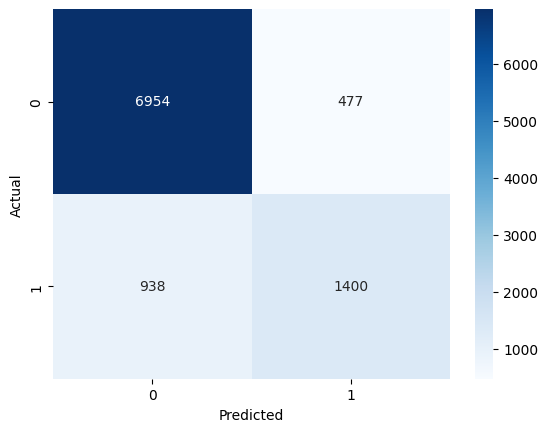

In [61]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predict_y)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [62]:
fp = x_test[(y_test == 0) & (predict_y == 1)]
fn = x_test[(y_test == 1) & (predict_y == 0)]

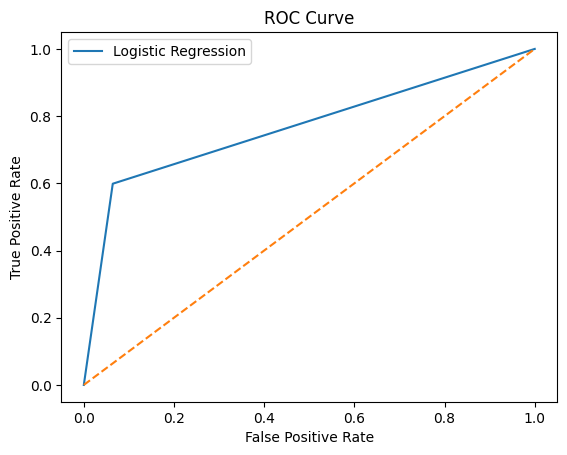

In [63]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, predict_y)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

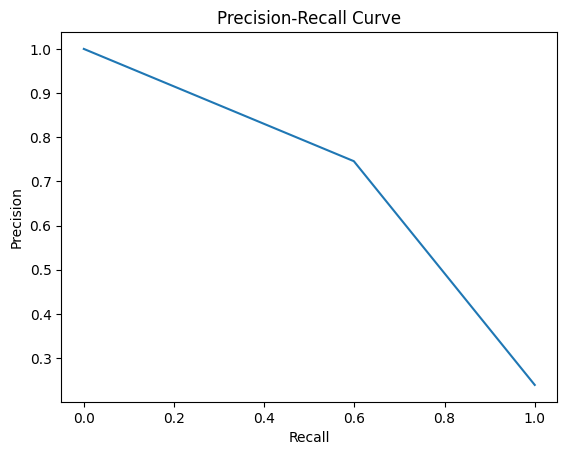

In [64]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, predict_y)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

ROC-кривая показала, что модель превосходит случайное угадывание, однако её способность разделять классы ограничена. Precision-Recall кривая демонстрирует выраженный trade-off: при увеличении полноты (recall) резко падает точность (precision), что указывает на сложности в выявлении класса с высоким доходом.

In [65]:
feature_groups = {
    "workclass": [col for col in coef.index if "workclass_" in col],
    "marital-status": [col for col in coef.index if "marital-status_" in col],
    "relationship": [col for col in coef.index if "relationship_" in col],
    "race": [col for col in coef.index if "race_" in col],
    "native-country": [col for col in coef.index if "native-country_" in col],
    "occupation" : [col for col in coef.index if "occupation_" in col]
}

group_importance = {}
group_importance["age"] = abs(coef["age"])
group_importance["hours-per-week"] = abs(coef["hours-per-week"])
group_importance["capital-gain"] = abs(coef["capital-gain"])
group_importance["capital-loss"] = abs(coef["capital-loss"])


for group, cols in feature_groups.items():
    group_importance[group] = coef[cols].abs().mean()

group_importance = pd.Series(group_importance).sort_values()

group_importance.plot(kind="barh", title="Aggregated Feature Importance")
plt.show()


NameError: name 'coef' is not defined

Relationship и merital-status коррелируюn (на 0.49). Нужно проверить важность признака для итогово результата модели. Сделаю это через запуск нескольких моделей...

Анализ важности признаков показал, что наибольшее влияние на предсказание оказывает capital-gain, что связано с прямой зависимостью инвестиционного дохода и общего дохода. Среди категориальных признаков наиболее значимым оказался marital-status, что отражает влияние социально-экономического положения. Признак workclass показал меньшую значимость, что может быть связано с высокой вариативностью доходов внутри категорий.

## проверка важности признаков. merital-status или relationship?

### без relastionship

In [ ]:
x_train_no_relationship = x_train.drop(
    columns=[col for col in x_train.columns if "relationship_" in col]
)
x_train_no_relationship

In [ ]:
x_test_no_relationship = x_test.drop(
    columns=[col for col in x_test.columns if "relationship_" in col]
)
x_test_no_relationship

In [ ]:
logistic_model_no_relationship = LogisticRegression(max_iter=1000)


logistic_model_no_relationship.fit(x_train_no_relationship, y_train)
y_pred_no_relationship = logistic_model_no_relationship.predict(x_test_no_relationship)
f1 = f1_score(y_test, y_pred_no_relationship)
f1

In [ ]:
roc_auc_score(y_test, y_pred_no_relationship)

### без merial-status

In [ ]:
x_train_no_merital_status = x_train.drop(
    columns=[col for col in x_train.columns if "merital-status_" in col]
)
x_train_no_merital_status

In [ ]:
x_test_no_merital_status = x_test.drop(
    columns=[col for col in x_test.columns if "merital-status_" in col]
)
x_test_no_merital_status

In [ ]:
logistic_model_no_merital_status = LogisticRegression(max_iter=1000)


logistic_model_no_merital_status.fit(x_train_no_merital_status, y_train)
y_pred_no_merital_status = logistic_model_no_merital_status.predict(x_test_no_merital_status)
f1 = f1_score(y_test, y_pred_no_merital_status)
f1

In [ ]:
roc_auc_score(y_test, y_pred_no_merital_status)

### Вывод: 

f1_score без отношений = 0.6598331346841478

f1_score без семейного статуса = 0.66429418742586 (т.е. вообще не изменилась от начальной точности)
(общие результат совпадает с roc_auc)

т.е. relationship показывает более точную информацию, в то время как matirial-status просто дублирует ее. 

Был проведён анализ влияния признаков marital-status и relationship. Удаление relationship привело к ухудшению качества модели (F1-score), тогда как удаление marital-status практически не повлияло на результат. Это указывает на избыточность признака marital-status, поэтому он был исключён из модели.

## проверка важности признаков: capital-gain, has_capital_gain

### только бинарные

In [ ]:
x_bin_train = x_train.drop(
    columns=["capital-gain", "capital-loss"]
)
x_bin_train["has_capital_gain"] = (x_train_original["capital-gain"] > 0).astype(int)
x_bin_train["has_capital_loss"] = (x_train_original["capital-loss"] > 0).astype(int)
x_bin_train

In [ ]:
x_bin_test = x_test.drop(
    columns=["capital-gain", "capital-loss"]
)
x_bin_test["has_capital_gain"] = (x_test_original["capital-gain"] > 0).astype(int)
x_bin_test["has_capital_loss"] = (x_test_original["capital-loss"] > 0).astype(int)
x_bin_test

In [ ]:
logistic_model_bin = LogisticRegression(max_iter=1000)


logistic_model_bin.fit(x_bin_train, y_train)
y_pred_bin = logistic_model_bin.predict(x_bin_test)
f1 = f1_score(y_test, y_pred_bin)
f1

In [ ]:
roc_auc_score(y_test, y_pred_bin)

f1 уменьшился((

### capital-gain + has_capital_gain

In [ ]:
x_gain_train = x_train.drop(
    columns=["capital-loss"]
)
x_gain_train["has_capital_gain"] = (x_train_original["capital-gain"] > 0).astype(int)
x_gain_train

In [ ]:
x_gain_test = x_test.drop(
    columns=["capital-loss"]
)
x_gain_test["has_capital_gain"] = (x_test_original["capital-gain"] > 0).astype(int)
x_gain_test

In [ ]:
logistic_model_gain = LogisticRegression(max_iter=1000)


logistic_model_gain.fit(x_gain_train, y_train)
y_pred_gain = logistic_model_gain.predict(x_gain_test)
f1 = f1_score(y_test, y_pred_gain)
f1

In [ ]:
roc_auc_score(y_test, y_pred_gain)

чуууть-чуть увеличалась точность))
Добавление бинарного признака has_capital_gain позволило немного улучшить качество модели (F1-score), что подтверждает наличие дополнительной информации в этом признаке, однако эффект оказался ограниченным.

### и бинарные и исходные

In [ ]:
x_loss_train = x_train.copy()
x_loss_train["has_capital_gain"] = (x_train_original["capital-gain"] > 0).astype(int)
x_loss_train["has_capital_loss"] = (x_train_original["capital-loss"] > 0).astype(int)
x_loss_train

In [ ]:
x_loss_test = x_test.copy()
x_loss_test["has_capital_gain"] = (x_test_original["capital-gain"] > 0).astype(int)
x_loss_test["has_capital_loss"] = (x_test_original["capital-loss"] > 0).astype(int)
x_loss_test

In [ ]:
logistic_model_loss = LogisticRegression(max_iter=1000)


logistic_model_loss.fit(x_loss_train, y_train)
y_pred_loss = logistic_model_loss.predict(x_loss_test)
f1 = f1_score(y_test, y_pred_loss)
f1

In [ ]:
roc_auc_score(y_test, y_pred_gain)

БЕРЕМ ПОСЛЕДНИЙ ВАРИАНТ

## поик оптимального порога

In [ ]:
import numpy as np
from sklearn.model_selection import StratifiedKFold

thresholds = np.arange(0.1, 0.91, 0.01)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

threshold_scores = []

for threshold in thresholds:
    fold_scores = []
    
    for train_idx, val_idx in cv.split(x_train, y_train):
        X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = LogisticRegression(max_iter=1000)
        model.fit(X_tr, y_tr)
        
        y_val_proba = model.predict_proba(X_val)[:, 1]
        y_val_pred = (y_val_proba >= threshold).astype(int)
        
        score = f1_score(y_val, y_val_pred)
        fold_scores.append(score)
    
    threshold_scores.append(np.mean(fold_scores))

best_idx = np.argmax(threshold_scores)
best_threshold = thresholds[best_idx]
best_cv_f1 = threshold_scores[best_idx]

print("Best threshold:", best_threshold)
print("Best CV F1:", best_cv_f1)

Best threshold: 0.32999999999999985
Best CV F1: 0.6896811088635175


## группируем native-county

In [86]:
x_train_country = x_train_original.copy()
x_test_country = x_test_original.copy()

x_train_country = prepare_date1(x_train_country)
x_test_country = prepare_date1(x_test_country)

country_counts = x_train_country["native-country"].value_counts()
rare_countries = country_counts[country_counts < 100].index

x_train_country["native-country-grouped"] = x_train_original["native-country"].replace(rare_countries, "Other")
x_test_country["native-country-grouped"] = x_test_original["native-country"].replace(rare_countries, "Other")

x_train_country = x_train_country.drop(columns = ["native-country"])
x_test_country = x_test_country.drop(columns = ["native-country"])

categorical_cols = [
    col for col in x_train_country.columns 
    if x_train_country[col].dtype == "object" and x_train_country[col].nunique() > 2]

x_train_country = prepare_date2(x_train_country, categorical_cols)
x_test_country = prepare_date2(x_test_country, categorical_cols)


x_train_country

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- native-country-grouped
Feature names seen at fit time, yet now missing:
- native-country


In [77]:
x_train_country["native-country-grouped"].value_counts()

native-country-grouped
United-States    35101
Other             1380
Mexico             763
?                  681
Philippines        243
Germany            166
Puerto-Rico        146
Canada             145
El-Salvador        121
India              117
Cuba               108
England            102
Name: count, dtype: int64